# Evaluating Model on Unseen Data

# Tools and Utils

In [1]:
# ----import tools----

#Data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, load_dataset
from huggingface_hub import login

# MLflow
import mlflow
import mlflow.transformers
from mlflow.tracking import MlflowClient

#text processing
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)


# Tensorflow and Keras and torch
import tensorflow as tf
import numpy as np
import torch
from torch.utils.data import DataLoader

#evaluation
import evaluate
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# I. Fetch Test Data

In [2]:
# load the data set
test_ds = Dataset.from_file('../data/processed/test_ds/data-00000-of-00001.arrow')
test_ds.to_pandas()['labels'].value_counts()

labels
fraud    1324
ham      1286
Name: count, dtype: int64

In [3]:
test_ds.to_pandas().head()

,text,labels
0,Important notice: Your prize claim requires ur...,fraud
1,Secure a free laptop! right away and enjoy exc...,ham
2,Important notice: Your prize claim requires ur...,fraud
3,Then ü ask dad to pick ü up lar... Ü wan 2 sta...,ham
4,"smallcap investment opportunity\n\ndrummond ,\...",fraud


# II.Load model from MLflow

In [4]:
# set tracking uri
mlflow.set_tracking_uri("http://localhost:8080")
# load the model and tokenizer from mlflow
model_run_id = "models:/m-0ec65a1c22bc4ab1ada2f5ddb7980a40"

# load component from mlflow
components = mlflow.transformers.load_model(model_run_id)
qlora_minilm = components.model
tokenizer = components.tokenizer

2026/05/13 15:46:14 INFO mlflow.transformers: 'models:/m-0ec65a1c22bc4ab1ada2f5ddb7980a40' resolved as 'mlflow-artifacts:/1/models/m-0ec65a1c22bc4ab1ada2f5ddb7980a40/artifacts'


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: microsoft/Multilingual-MiniLM-L12-H384
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


### Tokenize

In [5]:
# Encode data
labels2id = {"fraud":1,"ham":0}
encoded_test_ds = test_ds.map(lambda x: {"labels": labels2id[x['labels']]})

# tokenize the data set
tokenized_ds = encoded_test_ds.map(
    lambda x: tokenizer(x["text"], truncation=True, padding="max_length", max_length=256),
    batched=True,
)

tokenized_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print(tokenized_ds.features)
print(tokenized_ds)

{'text': Value('string'), 'labels': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}
Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 2610
})


# I. Evaluate Inference Performance

In [6]:
import time
from transformers import DataCollatorWithPadding
"""
#Initialize the collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#Pass it to DataLoader
loader = DataLoader(
    tokenized_ds, 
    batch_size=4, 
    collate_fn=data_collator  # This handles the variable lengths
)
"""

#MPS
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# inferance argss
loader = DataLoader(tokenized_ds, batch_size=4)
total_samples = 0
predictions = []
latencies = []
qlora_minilm.eval() 

# predict the labels
with torch.no_grad():
    for batch in loader:
        # get the input_ids and attention_mask
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # make prediction
        start_time = time.time() 
        outputs = qlora_minilm(input_ids=torch.tensor(input_ids), attention_mask=torch.tensor(attention_mask))
        logits = outputs.logits

        # preprocess output
        batch_predictions = torch.argmax(logits, dim=-1)
        end_time = time.time()

        #store the result
        predictions.extend(batch_predictions.cpu().tolist())
        latencies.append((end_time - start_time)*1000)

        #show progress and result
        print(f"progress:{len(predictions)}/{len(tokenized_ds)}")

#calculate throughput (sample/ms)
throughput = len(test_ds) / (np.sum(latencies) / 1000)

inference_metrics = {
    "p50_latency_ms": float(np.percentile(latencies, 50)),
    "p95_latency_ms": float(np.percentile(latencies, 95)),
    "p99_latency_ms": float(np.percentile(latencies, 99)),
    "throughput_req_sec": float(throughput)
}


/var/folders/tk/mn4_r_cn03ndtjss8b670dfw0000gn/T/ipykernel_44704/845446824.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputs = qlora_minilm(input_ids=torch.tensor(input_ids), attention_mask=torch.tensor(attention_mask))
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


progress:4/2610
progress:8/2610
progress:12/2610
progress:16/2610
progress:20/2610
progress:24/2610
progress:28/2610
progress:32/2610
progress:36/2610
progress:40/2610
progress:44/2610
progress:48/2610
progress:52/2610
progress:56/2610
progress:60/2610
progress:64/2610
progress:68/2610
progress:72/2610
progress:76/2610
progress:80/2610
progress:84/2610
progress:88/2610
progress:92/2610
progress:96/2610
progress:100/2610
progress:104/2610
progress:108/2610
progress:112/2610
progress:116/2610
progress:120/2610
progress:124/2610
progress:128/2610
progress:132/2610
progress:136/2610
progress:140/2610
progress:144/2610
progress:148/2610
progress:152/2610
progress:156/2610
progress:160/2610
progress:164/2610
progress:168/2610
progress:172/2610
progress:176/2610
progress:180/2610
progress:184/2610
progress:188/2610
progress:192/2610
progress:196/2610
progress:200/2610
progress:204/2610
progress:208/2610
progress:212/2610
progress:216/2610
progress:220/2610
progress:224/2610
progress:228/2610


   p50_latency_ms  p95_latency_ms  p99_latency_ms  throughput_req_sec
0       25.808811        48.42515      147.007799          125.452867


<Axes: >

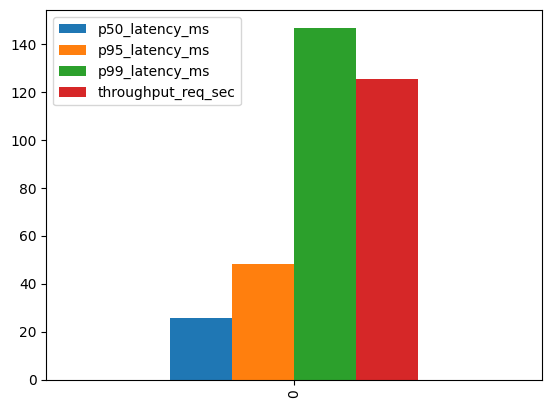

In [7]:
print(pd.DataFrame(inference_metrics, index=[0]))
pd.DataFrame(inference_metrics, index=[0]).plot(kind='bar')

# II. Evaluate Model Architecture

In [8]:
num_params = qlora_minilm.num_parameters()
memory_size = qlora_minilm.get_memory_footprint() / (1024**2)
width = qlora_minilm.config.hidden_size
length = qlora_minilm.config.num_hidden_layers

architecture_metrics = {
    "num_parameters": num_params,
    "model_width": width,
    "model_length": length,
    "memory_size_MB": memory_size,
}

pd.DataFrame(architecture_metrics, index=[0])

,num_parameters,model_width,model_length,memory_size_MB
0,118324996,384,12,226.972176


In [9]:
print("label vs prediction", list(zip(tokenized_ds["labels"], predictions)))

label vs prediction [(tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(0), 0), (tensor(0), 0), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(1), 0), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(1), 1), (te

# IV. Evaluate Performance

### Classification Report

In [10]:
pred_vs_actual = {"predictions":np.int8(predictions), 
                  "actual":np.int8(tokenized_ds["labels"])}
pred_vs_actual = pd.DataFrame(pred_vs_actual)

   accuracy  precision    recall  f1_score
0  0.975096   0.980168  0.970544  0.975332


<Axes: >

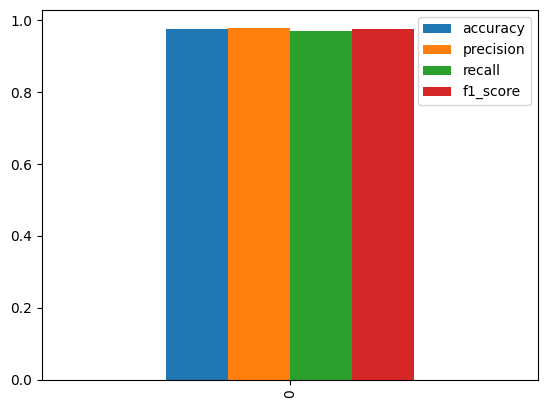

In [11]:
def compute_metrics(predictions, references):
    accuracy = accuracy_score(references, predictions)
    precision = precision_score(references, predictions)
    recall = recall_score(references, predictions)
    f1 = f1_score(references, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    }

# compute metrics
references = pred_vs_actual['actual']
performance_metrics = compute_metrics(pred_vs_actual['predictions'], references)
print(pd.DataFrame(performance_metrics,index=[0]))
pd.DataFrame(performance_metrics,index=[0]).plot(kind='bar')

### Confusion Metric

[[0.97978227 0.02021773]
 [0.02945619 0.97054381]]


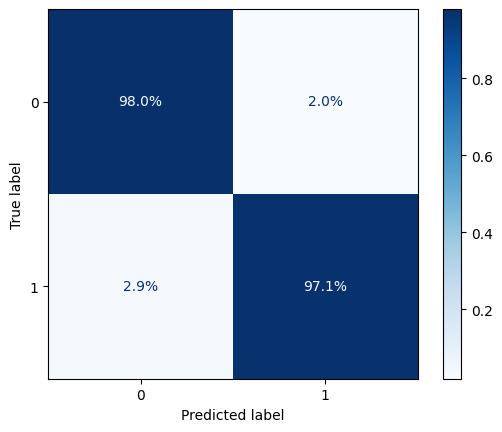

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 
cm = confusion_matrix(
    y_true=pred_vs_actual['actual'],
    y_pred=pred_vs_actual['predictions'],
    normalize='true'
)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, values_format='.1%')

# Print raw decimal values to the console
print(cm)
plt.show()


### Eror Analysis ()

In [ ]:
false_pred = pred_vs_actual[pred_vs_actual["predictions"] != pred_vs_actual["actual"]]
false_pred.value_counts()

predictions  actual
0            1         39
1            0         26
Name: count, dtype: int64

In [ ]:
def show_random_

### Per Class Performance (Classification Report)

### 

# Evaluating Model's Features Importance

### SHAP

### Attention Weight